In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import joblib

In [2]:
df = pd.read_csv('EURUSD_M15_20241030.csv', parse_dates=["Date"], index_col=0)

In [3]:
# target calculation
df['returns'] = df['Close'].pct_change()
df['target'] = (df['returns'] > 0).astype(int)
df['s_returns'] = df['returns']
df['cumulative_buy_and_hold_returns'] = df["returns"].cumsum().apply(np.exp)

# Shift price and returns to prevent lookahead bias
df['Close'] = df['Close'].shift(1)
df['Open'] = df['Open'].shift(1)
df['High'] = df['High'].shift(1)
df['Low'] = df['Low'].shift(1)
df['returns'] = df['returns'].shift(1)
df['volatility'] = df['returns'].rolling(window=8).std()
df['returns_div_volatility'] = df['returns'] / df['volatility'].replace(0, np.nan)
df['returns_inv'] = 1 / df['returns'].replace(0, np.nan)
df['volatility_inv'] = 1 / df['volatility'].replace(0, np.nan)
df[["lower", "mid","upper","bandwidth","percent"]] = ta.bbands(df["Close"], length=21, std=2)
df['distance'] = df['Close'] - df['mid']
df["position"] = np.where(df.Close < df.lower, 1, np.nan) # 1. oversold -> go long
df["position"] = np.where(df.Close > df.upper, -1, df["position"]) # 2. overbought -> go short
df["position"] = np.where(df.distance * df.distance.shift(1) < 0, 0, df["position"]) # 3. crossing SMA ("Middle Band") -> go neutral
df["position"] = df.position.ffill().fillna(0)

df.dropna(inplace=True)

#HMM
feature_matrix = df[['returns', 'volatility']]
scaler_hmm = StandardScaler()
feature_matrix_scaled = scaler_hmm.fit_transform(feature_matrix)
hmm_model = GaussianHMM(n_components = 5, covariance_type="full", n_iter = 100 , random_state=42)
hmm_model.fit(feature_matrix_scaled)
df['hmm_regime'] = hmm_model.predict(feature_matrix_scaled)
probabilities = hmm_model.predict_proba(feature_matrix_scaled)
df['hmm_prob_0'] = probabilities[:, 0]
df['hmm_prob_1'] = probabilities[:, 1]
df['hmm_prob_2'] = probabilities[:, 2]
df['hmm_prob_3'] = probabilities[:, 3]
df['hmm_prob_4'] = probabilities[:, 4]

# df[['stoch_k', 'stoch_d']] = ta.stoch(df['High'], df['Low'], df['Close'], 13, 3, 3)
# df['stoch'] = np.where(
#     (df['stoch_k'] > df['stoch_d']), 1,
#     np.where((df['stoch_k'] < df['stoch_d']), -1, 0)
# )


# df[["adx", "plus_di", "minus_di"]] = ta.adx(df["High"], df["Low"], df["Close"], length=13)
# df['adx_prev'] = df['adx'].shift(1)
# df['result'] = np.where((df['plus_di'] > df['minus_di']) & (df['adx'] > 25) & (df['adx'] > df['adx_prev']) & (df['Close'] > df['mid']), 1, np.nan)  # Long
# df['result'] = np.where((df['plus_di'] < df['minus_di']) & (df['adx'] > 25) & (df['adx'] > df['adx_prev']) & (df['Close'] < df['mid']), -1, df['result'])  # Short
# df['result'] = df['result'].ffill().fillna(0)

# # ADX and Bollinger Bands combined signal strategy without ML confirmation
# df[["adx", "plus_di", "minus_di"]] = ta.adx(df["High"], df["Low"], df["Close"], length=13)
# df[["lower", "mid","upper","bandwidth","percent"]] = ta.bbands(df["Close"], length=21, std=2)

# # ADX above 25: DI crossover signal
# df['position'] = np.where(
#     (df['adx'] > 25) & (df['plus_di'] > df['minus_di']), 1, 
#     np.where((df['adx'] > 25) & (df['plus_di'] < df['minus_di']), -1, np.nan)
# )

# # ADX <= 25: Bollinger Bands signal
# df['position'] = np.where(
#     (df['adx'] <= 25) & (df['Close'] < df['lower']), 1, 
#     np.where((df['adx'] <= 25) & (df['Close'] > df['upper']), -1, df['position'])
# )

# df['position'] = df['position'].ffill().fillna(0)

# Final clean up
df.replace([np.inf, -np.inf], 0, inplace=True)
df.dropna(inplace=True)

In [4]:
# features
features = df.drop(columns=['target', 's_returns', 'cumulative_buy_and_hold_returns', 'Close', 'Open', 'High', 'Low',"lower", "mid","upper","bandwidth","percent", 'position']).columns

# Define features and target
X = df[features]
y = df["target"]

# Apply StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert the scaled NumPy array back to a DataFrame
X = pd.DataFrame(X, columns=features)

In [5]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=500,
                                max_depth=5,
                                class_weight = 'balanced',
                                random_state=42)

model = rf_clf

# Train the model on the training set
model.fit(X_train, y_train)

# Predict and calculate accuracy for training and testing sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

accuracy_train = accuracy_score(y_train, y_pred_train) * 100
accuracy_test = accuracy_score(y_test, y_pred_test) * 100

# Print train and test accuracy
print(f"Train Accuracy: {accuracy_train:.2f}")
print(f"Test Accuracy: {accuracy_test:.2f}")

# Predict on the entire dataset
df['pred'] = model.predict(X)
total_accuracy = accuracy_score(df.target, df.pred) * 100
print(f"Total Accuracy: {total_accuracy:.2f}")

# Get predicted probabilities for each class
probs = model.predict_proba(X)

# Add these probabilities to the dataframe
df['prob_class_-1'] = probs[:, 0]
df['prob_class_1'] = probs[:, 1]
df['prob'] = np.where(df['prob_class_1'] > df['prob_class_-1'], df['prob_class_1'], df['prob_class_-1'])

Train Accuracy: 53.94
Test Accuracy: 53.66
Total Accuracy: 53.88


In [25]:
E_wlr_th = 0.899
E_raw_accuracy_th = 53
E_filtered_accuracy_th = 59
E_sharp_ratio_th = 13
E_max_dd_th = 0.04
E_position_count_th = 9500
E_cumulative_th = 1.6
E_annual_th = 1.2

In [26]:
objects_to_save = {
    'clf': model,
    'hmm': hmm_model,
    'scaler': scaler,
    'scaler_hmm': scaler_hmm,
    'wlr': E_wlr_th,
    'raw_accuracy': E_raw_accuracy_th,
    'filtered_accuracy': E_filtered_accuracy_th,
    'sharp_ratio': E_sharp_ratio_th,
    'max_dd': E_max_dd_th,
    'position_count': E_position_count_th,
    'cumulative': E_cumulative_th,
    'annual' : E_annual_th}
joblib.dump(objects_to_save, 'U_E.joblib')

['U_E.joblib']

# Filter and Evaluations

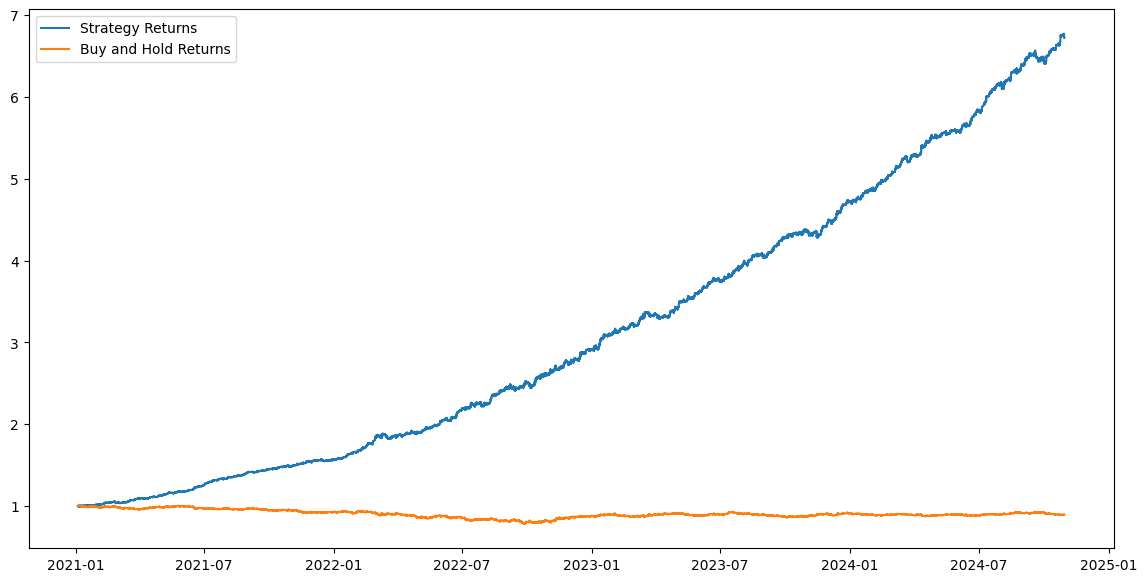

In [6]:
# strategy
df['pred'] = df['pred'].map({0: -1, 1: 1})
df['strategy'] = df['pred'] * df['s_returns']
df['cumulative_strategy_returns'] = df["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [7]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df['strategy']) * annualized_factor
std_return = np.std(df['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.51
Annualized Sharpe Ratio: 6.51
Maximum Drawdown: -0.04


In [8]:
print(df.target.value_counts())
print(df.pred.value_counts())
print(df.position.value_counts())

target
0    47227
1    46114
Name: count, dtype: int64
pred
 1    51989
-1    41352
Name: count, dtype: int64
position
 0.0    43747
 1.0    25117
-1.0    24477
Name: count, dtype: int64


In [9]:
# Calculate wins and losses, treating losses as positive values
df['loss'] = np.where(df['strategy'] < 0, abs(df['strategy']), np.nan)
df['win'] = np.where(df['strategy'] > 0, df['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df['win'].mean() / df['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df['kelly'] = (df['prob'] - (1 - df['prob']) / win_loss_ratio)
win_loss_ratio

array(0.96841799)

In [10]:
df.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,...,9.334100e+04,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,93341.000000,42190.000000,49679.000000,93341.000000
mean,1.101814,1.102150,1.101476,1.101814,-0.000001,0.494038,-0.000001,0.906150,0.000394,-0.000099,...,2.745608e-01,0.113958,0.500085,0.499915,0.519449,0.000020,3.114420,0.000322,0.000312,0.023227
std,0.058821,0.058767,0.058870,0.058819,0.000498,0.499967,0.000496,0.046254,0.000305,1.031029,...,4.207916e-01,0.993491,0.028017,0.028017,0.020166,0.000496,1.686377,0.000405,0.000371,0.040990
min,0.953840,0.955100,0.953490,0.953830,-0.011372,0.000000,-0.011372,0.784125,0.000014,-4.022394,...,0.000000e+00,-1.000000,0.216065,0.281693,0.500000,-0.016178,0.992063,0.000008,0.000008,-0.016306
25%,1.069340,1.069650,1.069030,1.069340,-0.000203,0.000000,-0.000199,0.881564,0.000201,-0.690714,...,8.797084e-08,-1.000000,0.483503,0.487763,0.507108,-0.000172,1.557644,0.000088,0.000093,-0.001857
50%,1.089300,1.089580,1.089030,1.089300,0.000008,0.000000,0.000000,0.899097,0.000313,0.020215,...,2.556249e-04,1.000000,0.496920,0.503080,0.515301,0.000027,2.746531,0.000200,0.000207,0.014794
75%,1.133950,1.134290,1.133640,1.133950,0.000203,1.000000,0.000200,0.928670,0.000487,0.692846,...,7.586022e-01,1.000000,0.512237,0.516497,0.525510,0.000224,4.346500,0.000413,0.000399,0.035546
max,1.234590,1.234860,1.234240,1.234590,0.016178,1.000000,0.016178,1.009437,0.005690,4.669246,...,9.999373e-01,1.000000,0.718307,0.783935,0.783935,0.010931,6.770531,0.016178,0.010931,0.560825


In [11]:
# df_filtered = df[(((df['position'] == 1) | (df['result'] == 1)) & (df['pred'] == 1)) | (((df['position'] == -1) | (df['result'] == -1)) & (df['pred'] == -1))].copy()

# df_filtered = df[((df['result'] == 1) & (df['pred'] == 1)) | ((df['result'] == -1) & (df['pred'] == -1))].copy()

# df_filtered = df[((df['position'] == 1) & (df['pred'] == 1) & (df['adx'] < 25)) | ((df['position'] == -1) & (df['pred'] == -1) & (df['adx'] < 25))].copy()

df_filtered = df[((df['position'] == 1) & (df['pred'] == 1)) | ((df['position'] == -1) & (df['pred'] == -1))].copy()

In [12]:
df_filtered

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 09:15:00,1.22553,1.22654,1.22534,1.22622,0.000539,1,0.000212,1.002790,0.000475,1.134225,...,0.999759,-1,0.527259,0.472741,0.527259,-0.000212,0.999453,0.000212,NaN,0.039100
2021-01-04 09:30:00,1.22622,1.22676,1.22593,1.22648,0.000212,1,0.000122,1.002913,0.000456,0.464534,...,0.999791,-1,0.523279,0.476721,0.523279,-0.000122,0.999331,0.000122,NaN,0.031011
2021-01-04 09:45:00,1.22645,1.22672,1.22628,1.22663,0.000122,0,-0.000261,1.002651,0.000457,0.267693,...,0.999430,-1,0.518837,0.481163,0.518837,0.000261,0.999592,NaN,0.000261,0.021982
2021-01-04 10:00:00,1.22663,1.22682,1.22561,1.22631,-0.000261,1,0.000408,1.003060,0.000429,-0.608223,...,0.960539,-1,0.500322,0.499678,0.500322,-0.000408,0.999184,0.000408,NaN,-0.015651
2021-01-04 10:15:00,1.22627,1.22702,1.22610,1.22681,0.000408,1,0.000277,1.003338,0.000281,1.453149,...,0.181986,-1,0.536136,0.463864,0.536136,-0.000277,0.998907,0.000277,NaN,0.057144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-29 14:30:00,1.07979,1.07985,1.07873,1.07874,-0.000982,0,-0.001010,0.891353,0.000347,-2.825789,...,0.872812,1,0.463584,0.536416,0.536416,-0.001010,6.745565,0.001010,NaN,0.057714
2024-10-29 14:45:00,1.07874,1.07879,1.07759,1.07765,-0.001010,1,0.000019,0.891369,0.000436,-2.318569,...,0.997638,1,0.465446,0.534554,0.534554,0.000019,6.745691,NaN,0.000019,0.053929
2024-10-29 15:00:00,1.07762,1.07815,1.07715,1.07767,0.000019,0,-0.000232,0.891163,0.000450,0.041258,...,0.999663,1,0.484157,0.515843,0.515843,-0.000232,6.744126,0.000232,NaN,0.015897


In [13]:
df_filtered['pred'] = df_filtered['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered.target, df_filtered.pred) * 100
accuracy

54.2063189950514

In [14]:
print(df_filtered.target.value_counts())
print(df_filtered.pred.value_counts())
# print(df_filtered.stoch.value_counts())

target
0    17421
1    16730
Name: count, dtype: int64
pred
1    18375
0    15776
Name: count, dtype: int64


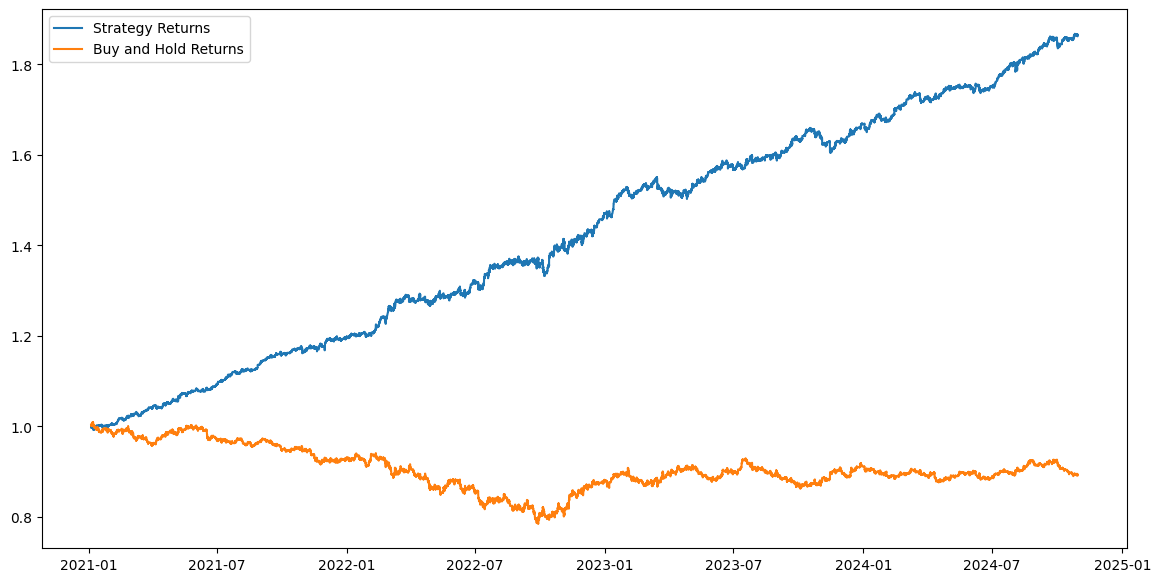

In [15]:
# strategy
df_filtered['pred'] = df_filtered['pred'].map({0: -1, 1: 1})
df_filtered['strategy'] = df_filtered['pred'] * df_filtered['s_returns']
df_filtered['cumulative_strategy_returns'] = df_filtered["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [16]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered['strategy']) * annualized_factor
std_return = np.std(df_filtered['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.46
Annualized Sharpe Ratio: 5.40
Maximum Drawdown: -0.03


In [17]:
# Calculate wins and losses, treating losses as positive values
df_filtered['loss'] = np.where(df_filtered['strategy'] < 0, abs(df_filtered['strategy']), np.nan)
df_filtered['win'] = np.where(df_filtered['strategy'] > 0, df_filtered['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered['win'].mean() / df_filtered['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered['kelly'] = (df_filtered['prob'] - (1 - df_filtered['prob']) / win_loss_ratio)
win_loss_ratio

array(0.9357627)

In [18]:
df_filtered.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,34151.000000,34151.000000,34151.000000,34151.000000,34151.000000,34151.000000,34151.000000,34151.000000,34151.000000,34151.000000,...,34151.000000,34151.000000,34151.000000,34151.000000,34151.000000,34151.000000,34151.000000,15380.000000,18282.000000,34151.000000
mean,1.101264,1.101625,1.100887,1.101253,-0.000011,0.489883,-0.000004,0.905655,0.000435,-0.020420,...,0.308911,0.076103,0.499708,0.500292,0.521331,0.000018,1.420310,0.000360,0.000337,0.009802
std,0.058868,0.058810,0.058922,0.058868,0.000536,0.499905,0.000534,0.046316,0.000328,1.064602,...,0.433267,0.997115,0.028017,0.028017,0.018167,0.000534,0.252068,0.000430,0.000393,0.037581
min,0.954980,0.955100,0.954130,0.954780,-0.010313,0.000000,-0.010931,0.784903,0.000023,-4.022394,...,0.000000,-1.000000,0.218548,0.284790,0.500000,-0.010313,0.992150,0.000008,0.000008,-0.034323
25%,1.068985,1.069335,1.068520,1.068940,-0.000202,0.000000,-0.000228,0.881114,0.000233,-0.620497,...,0.000003,-1.000000,0.479750,0.480846,0.511351,-0.000198,1.193378,0.000101,0.000102,-0.010843
50%,1.089090,1.089410,1.088760,1.089100,-0.000009,0.000000,0.000000,0.898800,0.000350,-0.032361,...,0.000998,1.000000,0.497031,0.502969,0.519673,0.000029,1.409681,0.000233,0.000228,0.006372
75%,1.133100,1.133410,1.132810,1.133130,0.000191,1.000000,0.000224,0.927989,0.000530,0.569375,...,0.910012,1.000000,0.519154,0.520250,0.527306,0.000248,1.634055,0.000468,0.000437,0.022162
max,1.234590,1.234860,1.234240,1.234590,0.009177,1.000000,0.008288,1.009437,0.005063,4.669246,...,0.999937,1.000000,0.715210,0.781452,0.781452,0.010931,1.867820,0.010313,0.010931,0.547902


In [19]:
df

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 05:15:00,1.22531,1.22545,1.22494,1.22533,0.000016,1,0.000269,1.002119,0.000253,0.064639,...,0.000000e+00,1,0.326180,0.673820,0.673820,0.000269,1.000269,NaN,0.000269,0.337002
2021-01-04 05:30:00,1.22531,1.22568,1.22520,1.22566,0.000269,0,-0.000261,1.001857,0.000226,1.189849,...,1.086452e-06,-1,0.525184,0.474816,0.525184,0.000261,1.000531,NaN,0.000261,0.034882
2021-01-04 05:45:00,1.22566,1.22567,1.22478,1.22534,-0.000261,1,0.000065,1.001923,0.000218,-1.198056,...,1.041121e-06,1,0.484138,0.515862,0.515862,0.000065,1.000596,NaN,0.000065,0.015936
2021-01-04 06:00:00,1.22534,1.22569,1.22509,1.22542,0.000065,0,-0.000294,1.001628,0.000211,0.309408,...,8.782547e-07,1,0.472685,0.527315,0.527315,-0.000294,1.000302,0.000294,NaN,0.039215
2021-01-04 06:15:00,1.22542,1.22542,1.22502,1.22506,-0.000294,0,-0.000204,1.001424,0.000208,-1.412505,...,7.620709e-07,1,0.483125,0.516875,0.516875,-0.000204,1.000098,0.000204,NaN,0.017994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-29 22:30:00,1.08147,1.08161,1.08141,1.08141,-0.000074,1,0.000240,0.894681,0.000221,-0.334087,...,7.246228e-06,1,0.492778,0.507222,0.507222,0.000240,6.728837,NaN,0.000240,-0.001627
2024-10-29 22:45:00,1.08141,1.08170,1.08141,1.08167,0.000240,0,0.000000,0.894681,0.000164,1.465203,...,4.551263e-07,-1,0.534245,0.465755,0.534245,-0.000000,6.728837,NaN,NaN,0.053300
2024-10-29 23:30:00,1.08135,1.08152,1.08121,1.08149,-0.000166,1,0.000009,0.894541,0.000133,-1.252160,...,4.914013e-09,1,0.499402,0.500598,0.500598,0.000009,6.728899,NaN,0.000009,-0.015090


In [20]:
df_filtered_2 = df_filtered[(df_filtered['kelly'] > 0)].copy()
df_filtered_2['pred'] = df_filtered_2['pred'].map({-1: 0, 1: 1})
accuracy = accuracy_score(df_filtered_2.target, df_filtered_2.pred) * 100
accuracy

56.034181200339816

In [21]:
df_filtered_2

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04 09:15:00,1.22553,1.22654,1.22534,1.22622,0.000539,1,0.000212,1.002790,0.000475,1.134225,...,0.999759,0,0.527259,0.472741,0.527259,-0.000212,0.999788,0.000212,NaN,0.022065
2021-01-04 09:30:00,1.22622,1.22676,1.22593,1.22648,0.000212,1,0.000122,1.002913,0.000456,0.464534,...,0.999791,0,0.523279,0.476721,0.523279,-0.000122,0.999666,0.000122,NaN,0.013832
2021-01-04 09:45:00,1.22645,1.22672,1.22628,1.22663,0.000122,0,-0.000261,1.002651,0.000457,0.267693,...,0.999430,0,0.518837,0.481163,0.518837,0.000261,0.999927,NaN,0.000261,0.004643
2021-01-04 10:15:00,1.22627,1.22702,1.22610,1.22681,0.000408,1,0.000277,1.003338,0.000281,1.453149,...,0.181986,0,0.536136,0.463864,0.536136,-0.000277,0.999242,0.000277,NaN,0.040428
2021-01-04 10:30:00,1.22681,1.22735,1.22650,1.22715,0.000277,1,0.001068,1.004410,0.000255,1.085242,...,0.162085,0,0.530434,0.469566,0.530434,-0.001068,0.998176,0.001068,NaN,0.028634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-29 13:15:00,1.08049,1.08050,1.07997,1.07999,-0.000463,0,-0.000231,0.893081,0.000273,-1.697774,...,0.000281,1,0.474959,0.525041,0.525041,-0.000231,1.866156,0.000231,NaN,0.017477
2024-10-29 13:30:00,1.08000,1.08001,1.07958,1.07974,-0.000231,1,0.000120,0.893188,0.000205,-1.130393,...,0.000072,1,0.478717,0.521283,0.521283,0.000120,1.866380,NaN,0.000120,0.009704
2024-10-29 14:30:00,1.07979,1.07985,1.07873,1.07874,-0.000982,0,-0.001010,0.891353,0.000347,-2.825789,...,0.872812,1,0.463584,0.536416,0.536416,-0.001010,1.862597,0.001010,NaN,0.041009


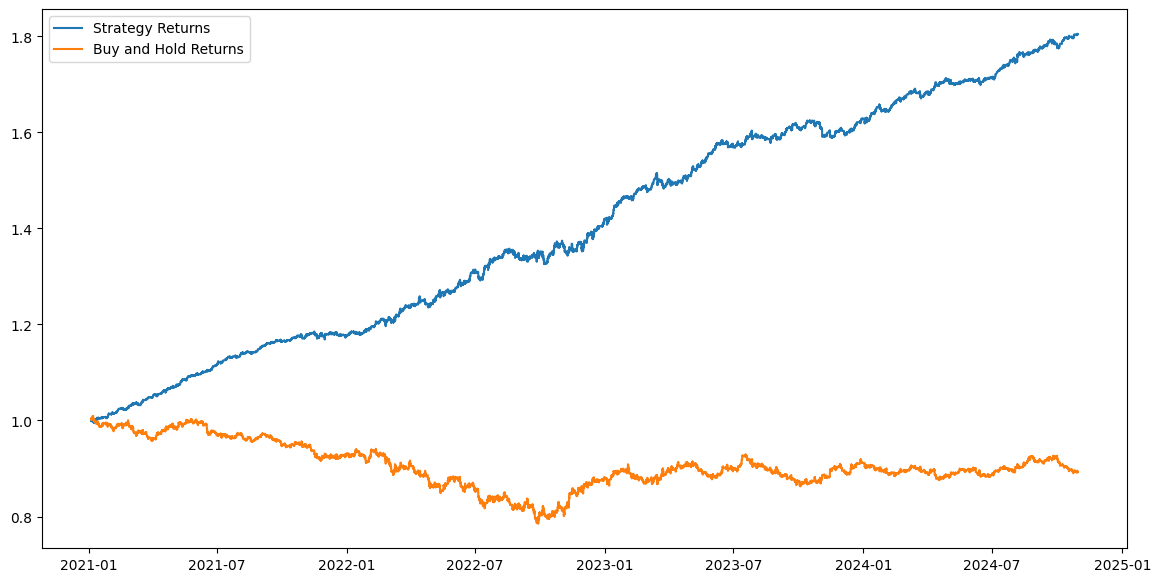

In [22]:
# strategy
df_filtered_2['pred'] = df_filtered_2['pred'].map({0: -1, 1: 1})
df_filtered_2['strategy'] = df_filtered_2['pred'] * df_filtered_2['s_returns']
df_filtered_2['cumulative_strategy_returns'] = df_filtered_2["strategy"].cumsum().apply(np.exp)

# plot
plt.figure(figsize=(14,7))
plt.plot(df_filtered_2['cumulative_strategy_returns'], label=f'Strategy Returns')
plt.plot(df_filtered_2['cumulative_buy_and_hold_returns'], label=f'Buy and Hold Returns')
plt.legend()
plt.show()

In [23]:
# Calculate wins and losses, treating losses as positive values
df_filtered_2['loss'] = np.where(df_filtered_2['strategy'] < 0, abs(df_filtered_2['strategy']), np.nan)
df_filtered_2['win'] = np.where(df_filtered_2['strategy'] > 0, df_filtered_2['strategy'], np.nan)

# Calculate the average win-to-loss ratio
win_loss_ratio = df_filtered_2['win'].mean() / df_filtered_2['loss'].mean()

# Handle cases where loss is zero or NaN
win_loss_ratio = np.where(np.isnan(win_loss_ratio) | (win_loss_ratio == 0), 1, win_loss_ratio)

# Calculate the Kelly Criterion using the improved formula
df_filtered_2['kelly'] = (df_filtered_2['prob'] - (1 - df_filtered_2['prob']) / win_loss_ratio)
win_loss_ratio

array(0.91796544)

In [24]:
# Actual returns associated with each trade
annualized_factor = 24960  # The number of 15-minute bars in a year
annualized_sreturn = np.mean(df_filtered_2['strategy']) * annualized_factor
print(f"Annualized Strategy Return: {annualized_sreturn:.2f}")

# Sharpe Ratio
risk_free_rate = 0  # Assuming risk-free rate is 0 for simplicity
mean_return = np.mean(df_filtered_2['strategy']) * annualized_factor
std_return = np.std(df_filtered_2['strategy']) * np.sqrt(annualized_factor)
sharpe_ratio = (mean_return - risk_free_rate) / std_return
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.2f}")


# Maximum Drawdown
def max_drawdown(strategy_returns):
    cumulative = np.cumsum(strategy_returns)
    drawdown = cumulative - np.maximum.accumulate(cumulative)
    return np.min(drawdown)

max_dd = max_drawdown(df_filtered_2['strategy'])
print(f"Maximum Drawdown: {max_dd:.2f}")

Annualized Strategy Return: 0.74
Annualized Sharpe Ratio: 8.26
Maximum Drawdown: -0.02


In [25]:
X.columns

Index(['returns', 'volatility', 'returns_div_volatility', 'returns_inv',
       'volatility_inv', 'distance', 'hmm_regime', 'hmm_prob_0', 'hmm_prob_1',
       'hmm_prob_2', 'hmm_prob_3', 'hmm_prob_4'],
      dtype='object')

In [26]:
df_filtered_2.describe()

,Open,High,Low,Close,returns,target,s_returns,cumulative_buy_and_hold_returns,volatility,returns_div_volatility,...,hmm_prob_4,pred,prob_class_-1,prob_class_1,prob,strategy,cumulative_strategy_returns,loss,win,kelly
count,20011.000000,20011.000000,20011.000000,20011.000000,20011.000000,20011.00000,20011.000000,20011.000000,20011.000000,20011.000000,...,2.001100e+04,20011.000000,20011.000000,20011.000000,20011.000000,20011.000000,20011.000000,8649.000000,11072.000000,20011.000000
mean,1.099531,1.099955,1.099084,1.099512,-0.000018,0.49148,-0.000002,0.904235,0.000437,-0.008972,...,3.260157e-01,0.041127,0.501046,0.498954,0.530130,0.000029,1.400172,0.000389,0.000358,0.018269
std,0.059405,0.059338,0.059471,0.059409,0.000683,0.49994,0.000565,0.046853,0.000311,1.337757,...,4.392802e-01,0.999179,0.035565,0.035565,0.018923,0.000564,0.233476,0.000473,0.000395,0.039537
min,0.954980,0.955100,0.954530,0.954780,-0.010313,0.00000,-0.010313,0.784903,0.000023,-4.022394,...,0.000000e+00,-1.000000,0.218548,0.284790,0.516594,-0.010313,0.995114,0.000008,0.000008,-0.010013
25%,1.067315,1.067740,1.066820,1.067225,-0.000373,0.00000,-0.000242,0.879529,0.000221,-1.070205,...,4.034519e-07,-1.000000,0.473593,0.474654,0.521915,-0.000197,1.181791,0.000107,0.000110,0.001106
50%,1.088480,1.088820,1.088080,1.088470,0.000028,0.00000,0.000000,0.898167,0.000366,0.158846,...,1.608988e-03,1.000000,0.482862,0.517138,0.525924,0.000046,1.364478,0.000247,0.000245,0.009483
75%,1.131715,1.132030,1.131285,1.131650,0.000330,1.00000,0.000239,0.926851,0.000556,1.019377,...,9.418704e-01,1.000000,0.525346,0.526407,0.530234,0.000275,1.605961,0.000506,0.000469,0.018488
max,1.233700,1.234600,1.233570,1.234590,0.009177,1.00000,0.008288,1.009274,0.005007,4.669246,...,9.999352e-01,1.000000,0.715210,0.781452,0.781452,0.008288,1.805357,0.010313,0.008288,0.543374
